#### Import libraries and load Dataset

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
housing_df = pd.read_csv('./housing.csv')
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Cleaning and Exploring**

In [42]:
housing_df.shape

(20640, 10)

**Observation:**
- 20 640 rows / data
- 10 columns / features




In [43]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [44]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


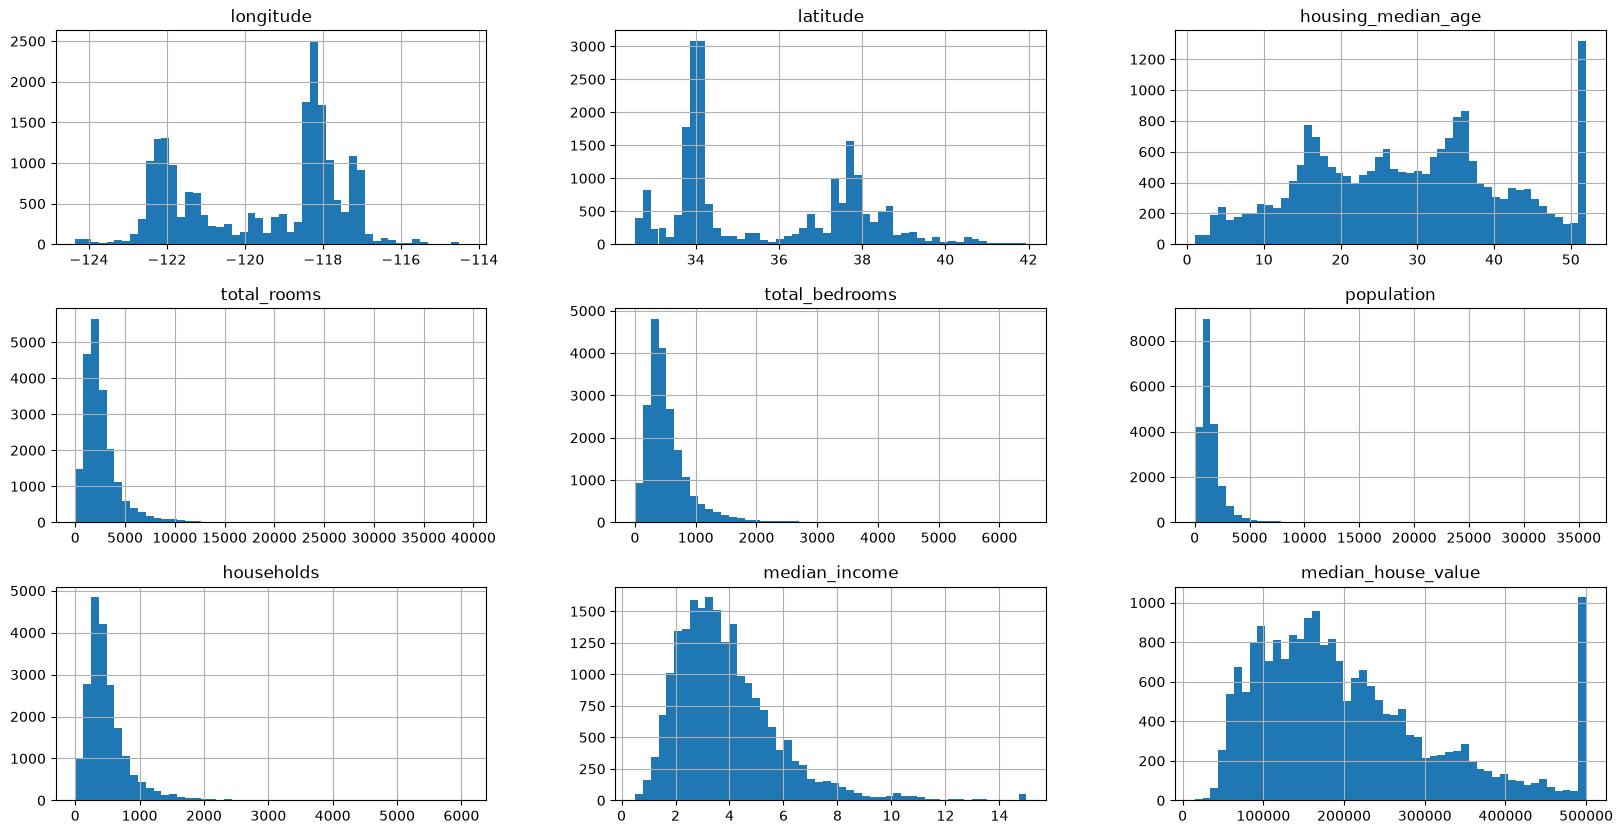

In [45]:
housing_df.hist(bins=50,figsize=(20,10))
plt.show()

Null rows

In [46]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [47]:
housing_df = housing_df.dropna()

In [48]:
housing_df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [49]:
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

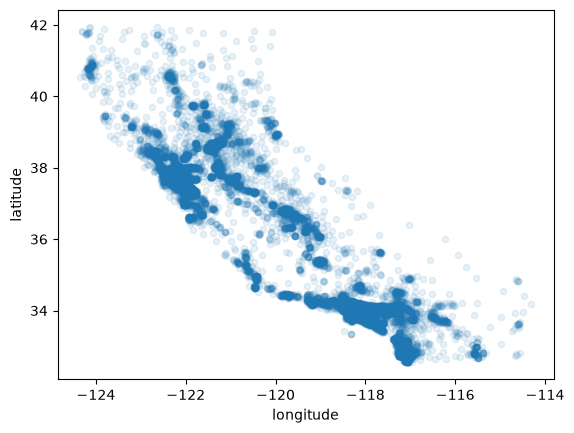

In [50]:
housing_df.plot(kind='scatter',x ='longitude',y='latitude',alpha = 0.1)
plt.show()

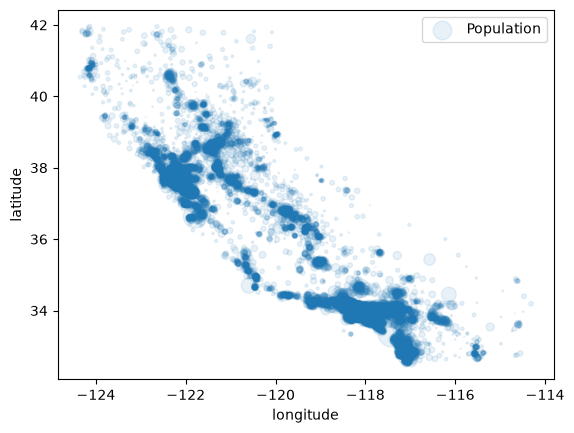

In [51]:
housing_df.plot(kind='scatter',x ='longitude',y='latitude',alpha = 0.1,
               s=housing_df['population']/100,label = 'Population')
plt.show()

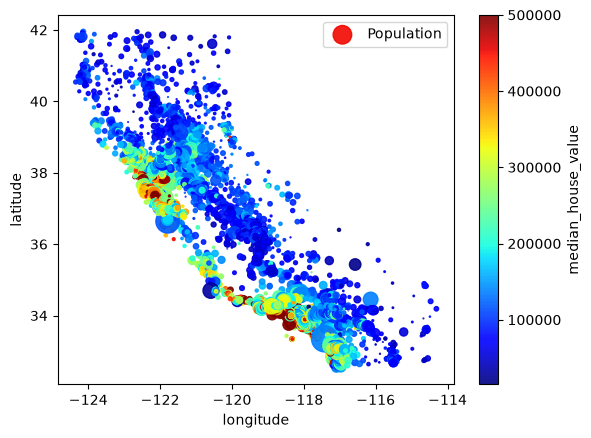

In [52]:
housing_df.plot(kind='scatter',x ='longitude',y='latitude',alpha = 0.9,
               s=housing_df['population']/100,label = 'Population',
                c='median_house_value',cmap =plt.get_cmap('jet') )
plt.show()

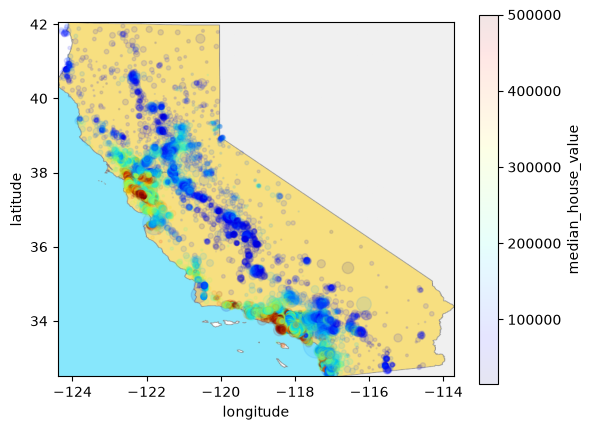

In [53]:
calif = plt.imread('./image/images.png')

housing_df.plot(kind='scatter',x ='longitude',y='latitude',alpha = 0.1,
               s=housing_df['population']/100,
                c='median_house_value',cmap =plt.get_cmap('jet') )

plt.imshow(calif, extent=[-124.4,-113.7,32.5,42.05],alpha=0.5,cmap=plt.get_cmap('jet'))

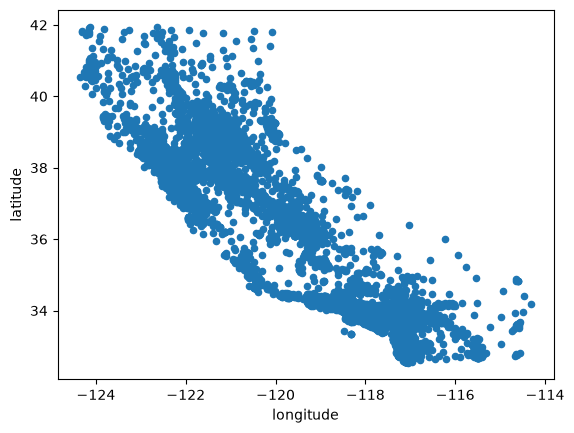

In [54]:
housing_df.plot(kind='scatter',x='longitude',y='latitude')
plt.show()

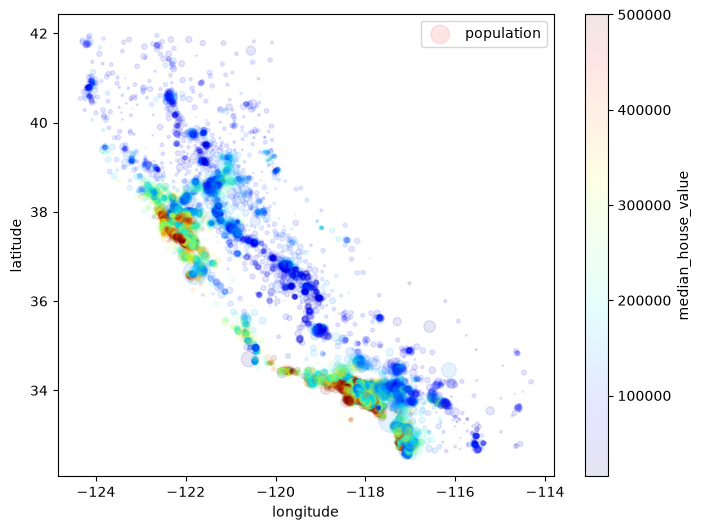

In [55]:
housing_df.plot(kind='scatter',x='longitude',y='latitude',alpha =0.1,s=housing_df['population']/100,label = 'population',
            c='median_house_value',cmap=plt.get_cmap("jet"), figsize=(8,6))
plt.show()


Correlation

# NEW NOTEBOOK

In [56]:
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Split data

In [57]:
housing_df = housing_df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity',
       'median_house_value']]


In [58]:
X = housing_df.iloc[:,:-1]
y = housing_df.iloc[:,-1]
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20433, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [61]:
num_cols = housing_df.select_dtypes(include='number').columns.tolist()
cat_cols = housing_df.select_dtypes(include=['object','string']).columns.tolist()


In [62]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
17727,-121.80,37.32,14.0,4412.0,924.0,2698.0,891.0,4.7027,<1H OCEAN
2057,-119.63,36.64,33.0,1036.0,181.0,620.0,174.0,3.4107,INLAND
6453,-118.06,34.12,25.0,3891.0,848.0,1848.0,759.0,3.6639,INLAND
4619,-118.31,34.07,28.0,2362.0,949.0,2759.0,894.0,2.2364,<1H OCEAN
15266,-117.27,33.04,27.0,1839.0,392.0,1302.0,404.0,3.5500,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...
11397,-117.97,33.72,24.0,2991.0,500.0,1437.0,453.0,5.4286,<1H OCEAN
12081,-117.54,33.76,5.0,5846.0,1035.0,3258.0,1001.0,4.7965,<1H OCEAN
5447,-118.42,34.01,42.0,1594.0,369.0,952.0,362.0,3.0990,<1H OCEAN
866,-122.04,37.57,12.0,5719.0,1064.0,3436.0,1057.0,5.2879,NEAR BAY


In [63]:
num_cols = ['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

Pipeline

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ]
)

Linear Regression()

In [65]:
from sklearn.linear_model import LinearRegression


pipeline1 = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [66]:
pipeline1.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [67]:
y_pred_train = pipeline1.predict(X_train)
y_pred_test = pipeline1.predict(X_test)


In [68]:
from sklearn.metrics import root_mean_squared_error

In [69]:

print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))


RMSE for Train:  68487.30666948423
RMSE for Test:  69297.7166911303


In [81]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline1,X_train,
    y_train,cv=kf,
    scoring='neg_root_mean_squared_error'
)

print(scores)
print(-scores.mean())

pipeline1.fit(X_train, y_train)
y_pred_train = pipeline1.predict(X_train)
y_pred_test = pipeline1.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))



[-66815.86955541 -68374.92075004 -68638.0880325  -70545.33486279
 -69220.53464064]
68718.94956827593
RMSE for Train:  68487.30666948423
RMSE for Test:  69297.7166911303


Random Forest

gbr = GradientBoostingRegressor(n_estimators=250)

knn = KNeighborsRegressor(n_neighbors=15)

In [70]:
from sklearn.ensemble import RandomForestRegressor
rfr = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',RandomForestRegressor(max_depth=10))
    ]
)

In [71]:
rfr.fit(X_train,y_train)
y_pred_train = rfr.predict(X_train)
y_pred_test = rfr.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))


RMSE for Train:  43007.64756652025
RMSE for Test:  53884.93059018467


In [83]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rfr,X_train,
    y_train,cv=5,
    scoring='neg_root_mean_squared_error'
)

print(scores)
print(-scores.mean())

rfr.fit(X_train, y_train)
y_pred_train = rfr.predict(X_train)
y_pred_test = rfr.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))



[-50913.45248224 -55622.46367278 -51609.66608415 -53886.41544521
 -54183.78160882]
53243.15585863929
RMSE for Train:  42986.50996316801
RMSE for Test:  54107.34416454881


In [82]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rfr,X_train,
    y_train,cv=kf,
    scoring='neg_root_mean_squared_error'
)

print(scores)
print(-scores.mean())

rfr.fit(X_train, y_train)
y_pred_train = rfr.predict(X_train)
y_pred_test = rfr.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))



[-51886.85250127 -53241.79578389 -53837.94575411 -54319.35429007
 -52233.93597469]
53103.97686080611
RMSE for Train:  43019.15153151524
RMSE for Test:  54056.208667977604


KNN 

In [72]:
from sklearn.neighbors import KNeighborsRegressor

knn  = Pipeline( steps=[
    ('preprocessor',preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=15))
]

)

In [73]:
knn.fit(X_train,y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))


RMSE for Train:  56070.79264366786
RMSE for Test:  61157.89760759497


In [88]:
scores = cross_val_score(knn,X=X_train,y=y_train,
                         cv=kf,scoring='neg_root_mean_squared_error')

print(scores)
print(-scores.mean())

knn.fit(X_train,y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))



[-59106.76922793 -60466.71451492 -62156.8192705  -62798.90294379
 -58931.33160472]
60692.1075123716
RMSE for Train:  56070.79264366786
RMSE for Test:  61157.89760759497


Gradient Boosting

In [74]:
from sklearn.ensemble import GradientBoostingRegressor

gb = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',GradientBoostingRegressor(n_estimators=250))
])

In [75]:
gb.fit(X_train,y_train)

y_pred_train = gb.predict(X_train)
y_pred_test = gb.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))


RMSE for Train:  46582.53675986517
RMSE for Test:  51759.89655213133


In [78]:
gb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [89]:
scores = cross_val_score(
    gb,X_train,y_train,cv=kf,scoring='neg_root_mean_squared_error')

print(scores)
print(-scores.mean())

gb.fit(X_train,y_train)

y_pred_train = gb.predict(X_train)
y_pred_test = gb.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))

[-49277.7510036  -49887.62863358 -52176.95975958 -51707.60799385
 -49882.19825098]
50586.4291283166
RMSE for Train:  46582.53675986517
RMSE for Test:  51773.94410057711


XGBOOst

In [76]:
from xgboost import XGBRegressor

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',XGBRegressor())
])

In [91]:
scores = cross_val_score(xgb, X_train,
                         y_train,cv=kf,scoring='neg_root_mean_squared_error')

print(scores)
print(-scores.mean())

xgb.fit(X_train,y_train)


y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))

[-45947.44562991 -47211.14040665 -48578.53466806 -48546.3970653
 -46670.53440129]
47390.81043424197
RMSE for Train:  28026.78248934251
RMSE for Test:  48248.52228254719


print('')

### OLD NOTEBOOK

In [18]:
#housing_df.corr()

In [19]:
housing_df_shuffled = housing_df.sample(n=len(housing_df),random_state=1)
housing_df_shuffled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6715,-118.18,34.14,38.0,3039.0,487.0,1131.0,465.0,7.7116,360900.0,<1H OCEAN
4121,-118.19,34.14,38.0,1826.0,300.0,793.0,297.0,5.2962,291500.0,<1H OCEAN
15433,-117.25,33.20,10.0,2050.0,473.0,1302.0,471.0,2.7961,131300.0,<1H OCEAN
20272,-119.23,34.19,16.0,5297.0,810.0,1489.0,667.0,6.4522,500001.0,NEAR OCEAN
11843,-120.93,39.96,15.0,1666.0,351.0,816.0,316.0,2.9559,118800.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
11065,-117.88,33.79,32.0,1484.0,295.0,928.0,295.0,5.1418,190300.0,<1H OCEAN
17455,-120.43,34.70,26.0,2353.0,389.0,1420.0,389.0,3.8700,125800.0,NEAR OCEAN
5249,-118.45,34.08,52.0,1500.0,176.0,384.0,145.0,7.1576,500001.0,<1H OCEAN
12290,-116.97,33.94,29.0,3197.0,632.0,1722.0,603.0,3.0432,91200.0,INLAND


In [20]:
pd.get_dummies(housing_df_shuffled['ocean_proximity'],dtype=int).head()

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6715,1,0,0,0,0
4121,1,0,0,0,0
15433,1,0,0,0,0
20272,0,0,0,0,1
11843,0,1,0,0,0


In [21]:
housing_df_final = pd.concat([(housing_df_shuffled.drop('ocean_proximity',axis=1)),
                              (pd.get_dummies(housing_df_shuffled['ocean_proximity'],dtype=int))],axis=1)

housing_df_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6715,-118.18,34.14,38.0,3039.0,487.0,1131.0,465.0,7.7116,360900.0,1,0,0,0,0
4121,-118.19,34.14,38.0,1826.0,300.0,793.0,297.0,5.2962,291500.0,1,0,0,0,0
15433,-117.25,33.20,10.0,2050.0,473.0,1302.0,471.0,2.7961,131300.0,1,0,0,0,0
20272,-119.23,34.19,16.0,5297.0,810.0,1489.0,667.0,6.4522,500001.0,0,0,0,0,1
11843,-120.93,39.96,15.0,1666.0,351.0,816.0,316.0,2.9559,118800.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11065,-117.88,33.79,32.0,1484.0,295.0,928.0,295.0,5.1418,190300.0,1,0,0,0,0
17455,-120.43,34.70,26.0,2353.0,389.0,1420.0,389.0,3.8700,125800.0,0,0,0,0,1
5249,-118.45,34.08,52.0,1500.0,176.0,384.0,145.0,7.1576,500001.0,1,0,0,0,0
12290,-116.97,33.94,29.0,3197.0,632.0,1722.0,603.0,3.0432,91200.0,0,1,0,0,0


In [22]:
corr_matrix = housing_df_final.corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,0.320831,-0.055337,0.009501,-0.474714,0.046185
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,-0.446928,0.351084,-0.016662,0.358785,-0.161342
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,0.045553,-0.236968,0.017105,0.256149,0.020797
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,-0.003777,0.026477,-0.007603,-0.023647,-0.008674
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.018314,-0.006463,-0.004361,-0.019873,0.000679
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,0.073450,-0.019602,-0.010451,-0.061480,-0.023498
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,0.041883,-0.038265,-0.009119,-0.011280,0.002106
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,0.168715,-0.237536,-0.009281,0.056677,0.027351
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,0.257614,-0.484787,0.023525,0.160526,0.140378
<1H OCEAN,0.320831,-0.446928,0.045553,-0.003777,0.018314,0.073450,0.041883,0.168715,0.257614,1.000000,-0.607778,-0.013928,-0.314721,-0.342018


In [23]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688355
<1H OCEAN             0.257614
NEAR BAY              0.160526
NEAR OCEAN            0.140378
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
ISLAND                0.023525
population           -0.025300
longitude            -0.045398
latitude             -0.144638
INLAND               -0.484787
Name: median_house_value, dtype: float64

**Feature Engineering**

In [24]:
housing_df_final['bedrooms_per_room'] = housing_df_final['total_bedrooms'] / housing_df_final['total_rooms']
housing_df_final['population_per_household'] = housing_df_final['population']/ housing_df_final['households']
housing_df_final['rooms_per_household'] = housing_df_final['total_rooms']/housing_df_final['households']

In [25]:
corr_matrix = housing_df_final.corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688355
<1H OCEAN                   0.257614
NEAR BAY                    0.160526
rooms_per_household         0.151344
NEAR OCEAN                  0.140378
total_rooms                 0.133294
housing_median_age          0.106432
households                  0.064894
total_bedrooms              0.049686
ISLAND                      0.023525
population_per_household   -0.023639
population                 -0.025300
longitude                  -0.045398
latitude                   -0.144638
bedrooms_per_room          -0.255880
INLAND                     -0.484787
Name: median_house_value, dtype: float64

<Axes: >

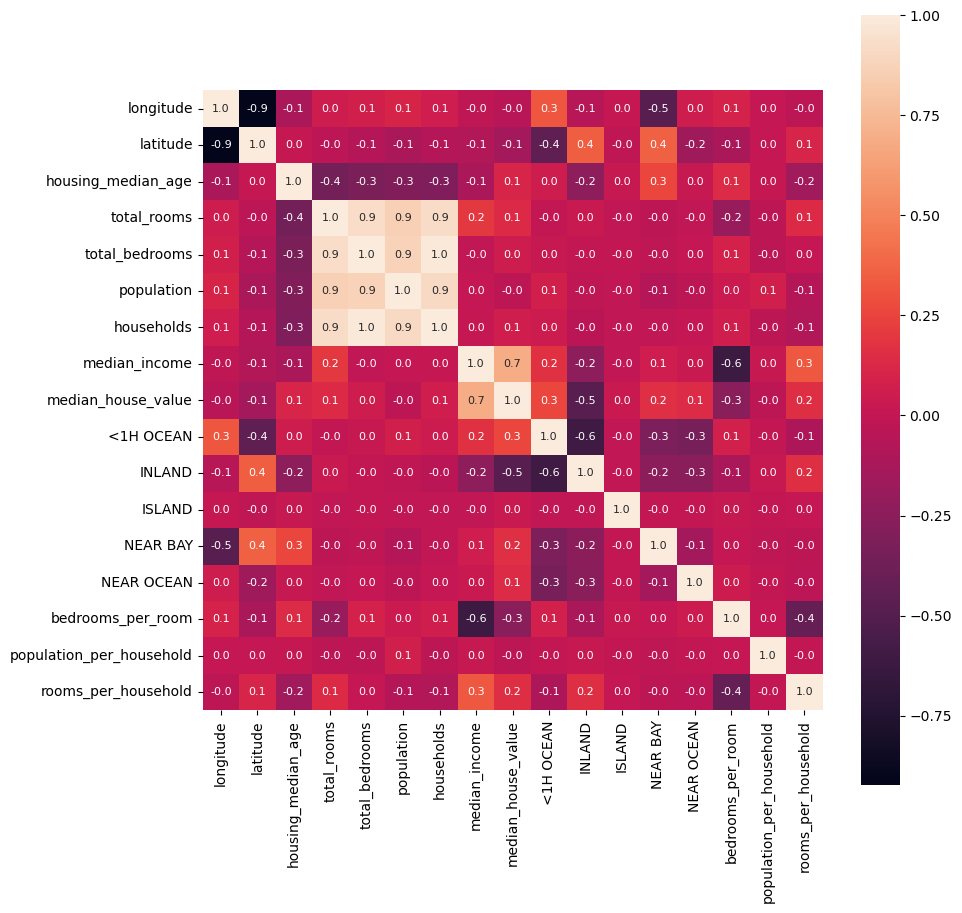

In [26]:
import seaborn as sns



plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,cbar=True,square=True,fmt='.1f',
            annot=True,annot_kws={'size':8})

<Axes: >

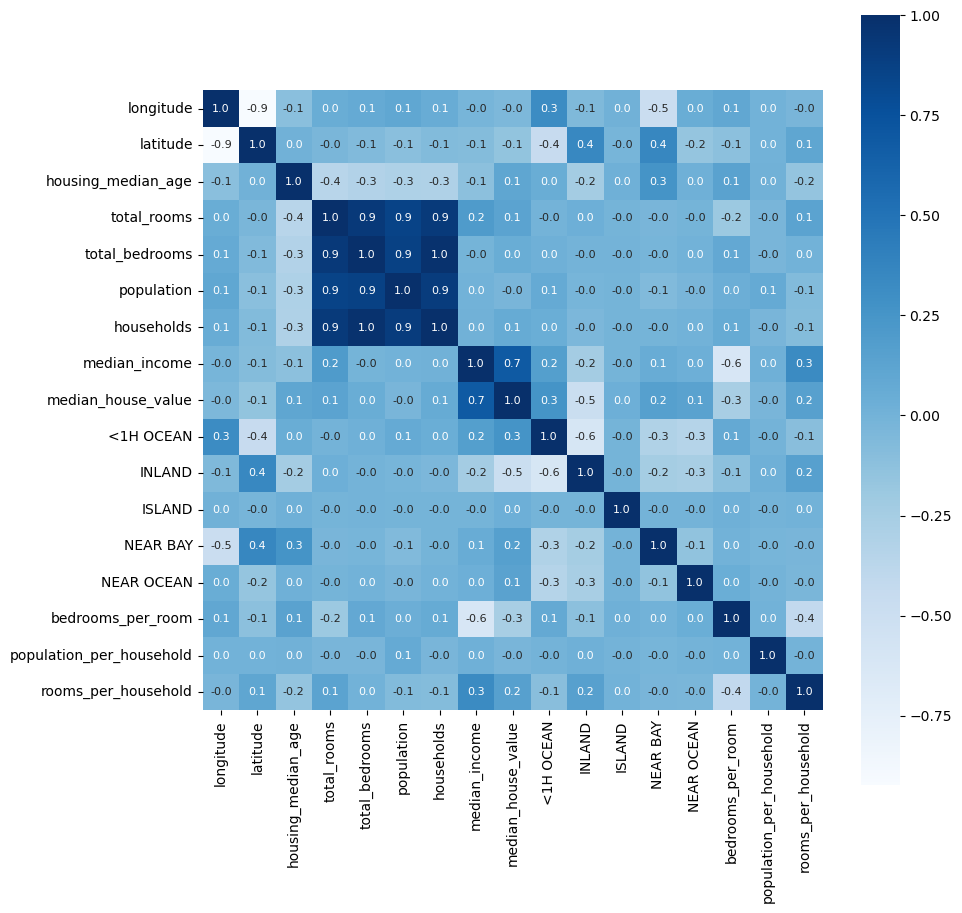

In [27]:
import seaborn as sns



plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,cbar=True,square=True,fmt='.1f',
            annot=True,annot_kws={'size':8},cmap='Blues')

In [28]:
columns = ['median_house_value','median_income', '<1H OCEAN', 
       'bedrooms_per_room', 'INLAND']

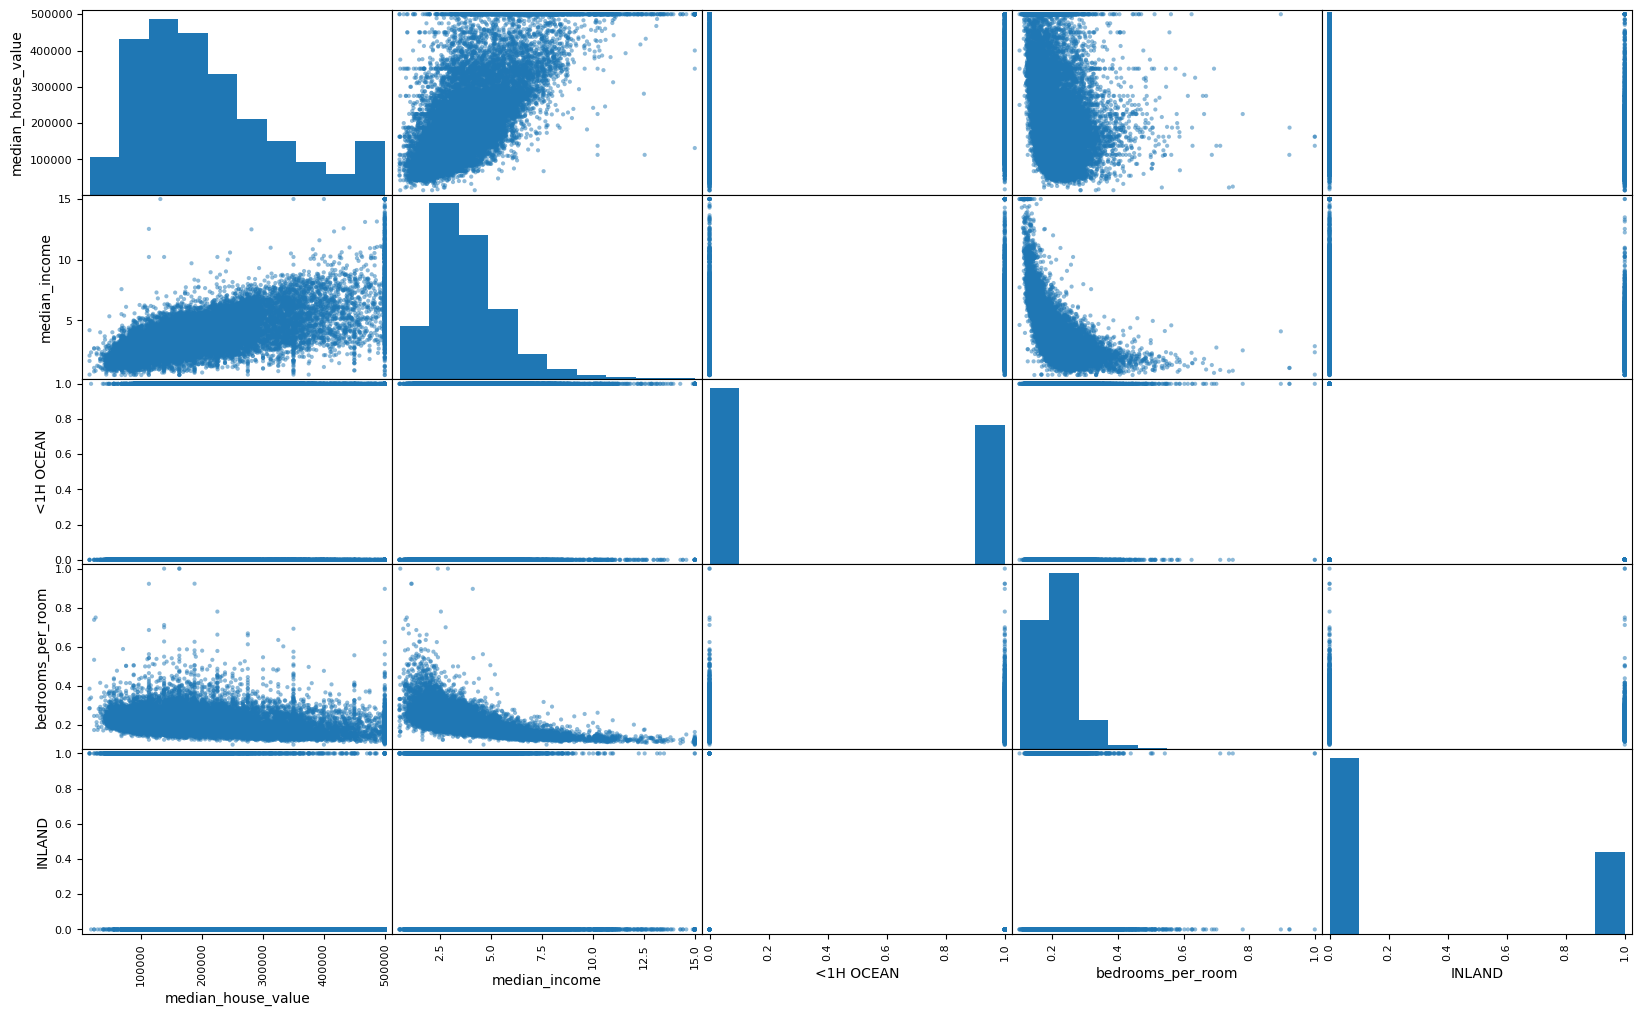

In [29]:
from pandas.plotting import scatter_matrix

scatter_matrix(housing_df_final[columns], figsize=(20, 12))
plt.show()

**Observation:** The new created feature `bedrooms_per_room` shows the high correralation:
- Houses with less bedroom will tend to be more expensive

In [30]:
corr_matrix = housing_df_final.corr()
df = corr_matrix['median_house_value'].sort_values(ascending=False)

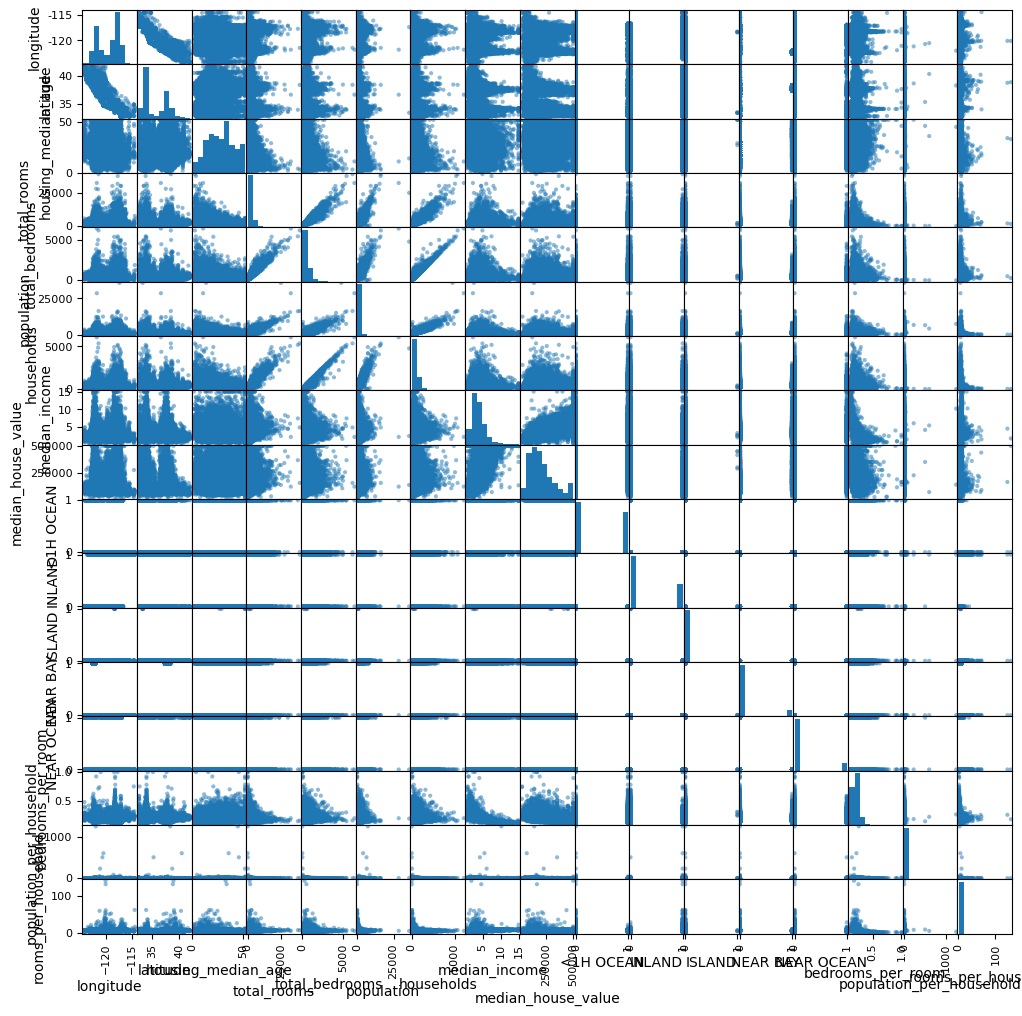

In [31]:
from pandas.plotting import scatter_matrix

scatter_matrix(housing_df_final, figsize=(12, 12))
plt.show()

In [32]:
housing_df_final.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', '<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY',
       'NEAR OCEAN', 'bedrooms_per_room', 'population_per_household',
       'rooms_per_household'],
      dtype='str')

In [33]:
column = [ 'median_house_value','bedrooms_per_room', 'population_per_household',
       'rooms_per_household']



In [34]:
'''
fig,ax = plt.subplots(2,2)
for i, col in enumerate(column):
    if i < 3:
        ax[0,i].plot(x=housing_df_final[col],)
    else:
        ax[]

    '''

'\nfig,ax = plt.subplots(2,2)\nfor i, col in enumerate(column):\n    if i < 3:\n        ax[0,i].plot(x=housing_df_final[col],)\n    else:\n        ax[]\n\n    '

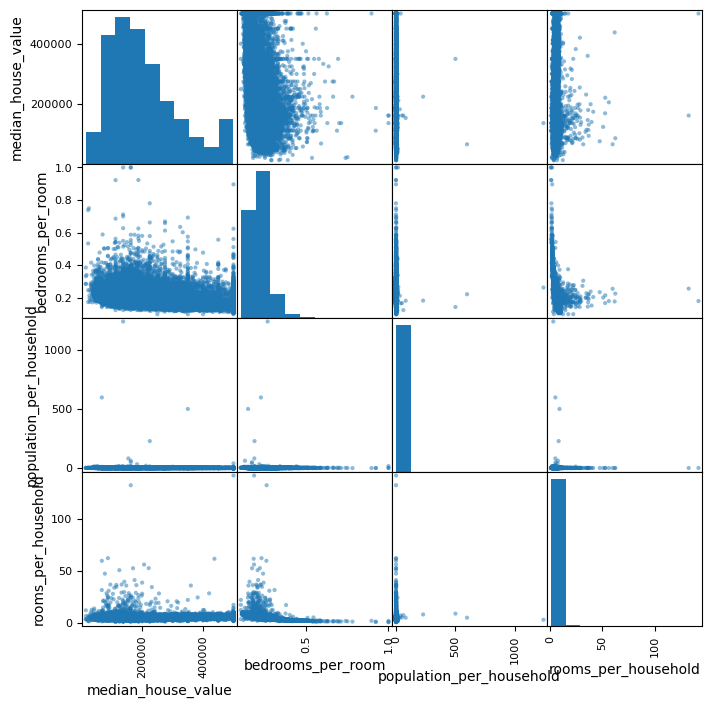

In [35]:
from pandas.plotting import scatter_matrix

scatter_matrix(housing_df_final[column],figsize=(8,8))
plt.show()

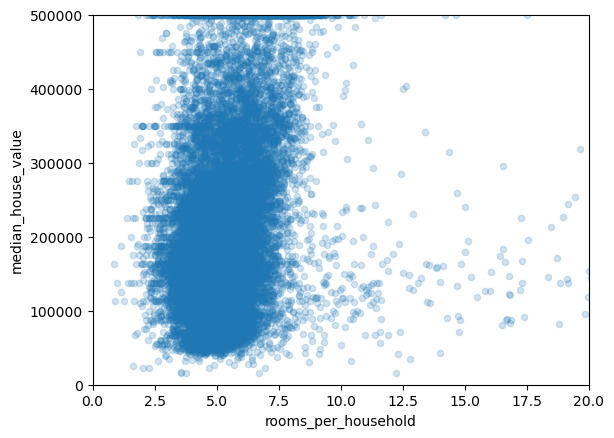

In [36]:
# do scatter for the three created features
housing_df_final.plot(kind='scatter',x='rooms_per_household',y='median_house_value',alpha=0.2)
plt.axis([0,20,0,500000])
plt.show()

In [37]:
housing_df_final.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', '<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY',
       'NEAR OCEAN', 'bedrooms_per_room', 'population_per_household',
       'rooms_per_household'],
      dtype='str')

In [38]:
housing_df_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedrooms_per_room,population_per_household,rooms_per_household
6715,-118.18,34.14,38.0,3039.0,487.0,1131.0,465.0,7.7116,360900.0,1,0,0,0,0,0.160250,2.432258,6.535484
4121,-118.19,34.14,38.0,1826.0,300.0,793.0,297.0,5.2962,291500.0,1,0,0,0,0,0.164294,2.670034,6.148148
15433,-117.25,33.20,10.0,2050.0,473.0,1302.0,471.0,2.7961,131300.0,1,0,0,0,0,0.230732,2.764331,4.352442
20272,-119.23,34.19,16.0,5297.0,810.0,1489.0,667.0,6.4522,500001.0,0,0,0,0,1,0.152917,2.232384,7.941529
11843,-120.93,39.96,15.0,1666.0,351.0,816.0,316.0,2.9559,118800.0,0,1,0,0,0,0.210684,2.582278,5.272152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11065,-117.88,33.79,32.0,1484.0,295.0,928.0,295.0,5.1418,190300.0,1,0,0,0,0,0.198787,3.145763,5.030508
17455,-120.43,34.70,26.0,2353.0,389.0,1420.0,389.0,3.8700,125800.0,0,0,0,0,1,0.165321,3.650386,6.048843
5249,-118.45,34.08,52.0,1500.0,176.0,384.0,145.0,7.1576,500001.0,1,0,0,0,0,0.117333,2.648276,10.344828
12290,-116.97,33.94,29.0,3197.0,632.0,1722.0,603.0,3.0432,91200.0,0,1,0,0,0,0.197685,2.855721,5.301824


In [39]:
housing_df_final = housing_df_final[['longitude', 'latitude', 
                                     'housing_median_age', 'total_rooms',
                                    'total_bedrooms', 'population', 'households', 
                                    'median_income', '<1H OCEAN', 'INLAND', 'ISLAND',
                                    'NEAR BAY','NEAR OCEAN','median_house_value']]

housing_df_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
6715,-118.18,34.14,38.0,3039.0,487.0,1131.0,465.0,7.7116,1,0,0,0,0,360900.0
4121,-118.19,34.14,38.0,1826.0,300.0,793.0,297.0,5.2962,1,0,0,0,0,291500.0
15433,-117.25,33.20,10.0,2050.0,473.0,1302.0,471.0,2.7961,1,0,0,0,0,131300.0
20272,-119.23,34.19,16.0,5297.0,810.0,1489.0,667.0,6.4522,0,0,0,0,1,500001.0
11843,-120.93,39.96,15.0,1666.0,351.0,816.0,316.0,2.9559,0,1,0,0,0,118800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11065,-117.88,33.79,32.0,1484.0,295.0,928.0,295.0,5.1418,1,0,0,0,0,190300.0
17455,-120.43,34.70,26.0,2353.0,389.0,1420.0,389.0,3.8700,0,0,0,0,1,125800.0
5249,-118.45,34.08,52.0,1500.0,176.0,384.0,145.0,7.1576,1,0,0,0,0,500001.0
12290,-116.97,33.94,29.0,3197.0,632.0,1722.0,603.0,3.0432,0,1,0,0,0,91200.0


**Split the dataset into Train, Test, and Validation**

In [40]:
len(housing_df_final)

20433

NEW NOTEBOOK

In [41]:
housing_df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [42]:
housing_df_final.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
6715,-118.18,34.14,38.0,3039.0,487.0,1131.0,465.0,7.7116,1,0,0,0,0,360900.0
4121,-118.19,34.14,38.0,1826.0,300.0,793.0,297.0,5.2962,1,0,0,0,0,291500.0


Pipeline

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [44]:
housing_df_final.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
<1H OCEAN               int32
INLAND                  int32
ISLAND                  int32
NEAR BAY                int32
NEAR OCEAN              int32
median_house_value    float64
dtype: object

In [ ]:
num_cols = []

OLD NOTEBOOK

In [42]:
train_df,test_df,val_df = housing_df_final[:18000],housing_df_final[18000:19217],housing_df_final[19215:]
len(train_df),len(test_df),len(val_df)

(18000, 1217, 1218)

In [43]:
train_df.shape

(18000, 14)

In [44]:
X_train, y_train = train_df.to_numpy()[:,:-1],train_df.to_numpy()[:,-1]
X_val,y_val = val_df.to_numpy()[:,:-1],val_df.to_numpy()[:,-1]
X_test, y_test = test_df.to_numpy()[:,:-1],test_df.to_numpy()[:,-1]

In [45]:
X_train.shape,y_train.shape,X_val.shape,y_val.shape,X_test.shape, y_test.shape

((18000, 13), (18000,), (1218, 13), (1218,), (1217, 13), (1217,))

**Preprocessing**

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler().fit(X_train[:,:8])

def preprocessor(X):
    A = np.copy(X)
    A[:,:8] = scaler.transform(A[:,:8])
    return A

X_train_preprocessed = preprocessor(X_train)
X_train_preprocessed

array([[ 0.69392289, -0.70053879,  0.74143687, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.68893867, -0.70053879,  0.74143687, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.15745562, -1.14052818, -1.48161665, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.01566556,  0.48836873,  0.6620421 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.62414377, -0.74734617,  0.82083164, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.24218741, -0.75670765, -0.68766897, ...,  0.        ,
         0.        ,  0.        ]])

In [48]:
pd.DataFrame(X_train_preprocessed)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.693923,-0.700539,0.741437,0.182633,-0.122416,-0.260140,-0.091604,2.014418,1.0,0.0,0.0,0.0,0.0
1,0.688939,-0.700539,0.741437,-0.373149,-0.567950,-0.556345,-0.533151,0.746260,1.0,0.0,0.0,0.0,0.0
2,1.157456,-1.140528,-1.481617,-0.270515,-0.155772,-0.110285,-0.075835,-0.566367,1.0,0.0,0.0,0.0,0.0
3,0.170579,-0.677135,-1.005248,1.217221,0.647142,0.053592,0.439303,1.353195,0.0,0.0,0.0,0.0,1.0
4,-0.676738,2.023651,-1.084643,-0.446459,-0.446441,-0.536189,-0.483214,-0.482468,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,-1.444309,0.993888,1.852964,0.623410,0.644759,0.401502,0.673218,-0.289257,0.0,0.0,0.0,1.0,0.0
17996,0.753734,-0.836280,-1.005248,1.012869,0.447009,0.963240,0.536549,1.123232,1.0,0.0,0.0,0.0,0.0
17997,-1.015666,0.488369,0.662042,0.233033,0.701940,1.777366,0.757322,-0.535863,1.0,0.0,0.0,0.0,0.0
17998,0.624144,-0.747346,0.820832,-0.616905,-0.496474,-0.252253,-0.491099,-0.850251,1.0,0.0,0.0,0.0,0.0


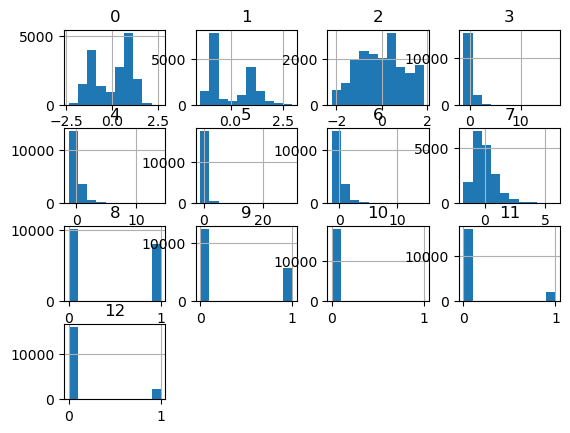

In [49]:

pd.DataFrame(X_train_preprocessed).hist()
plt.show()

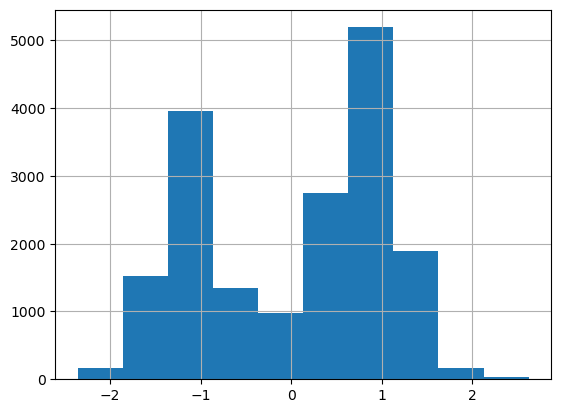

In [50]:
pd.DataFrame(X_train_preprocessed)[0].hist()
plt.show()

In [51]:
X_train,X_val,X_test = preprocessor(X_train),preprocessor(X_val),preprocessor(X_test)

In [52]:
X_train.shape,X_val.shape,X_test.shape

((18000, 13), (1218, 13), (1217, 13))

**Model**

In [53]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

**Linear Model**

In [54]:
lm = LinearRegression()
lm.fit(X_train,y_train)
mse = mean_squared_error(lm.predict(X_train),y_train)
print('Mean Squared error: ',mse)
rmse = mean_squared_error(lm.predict(X_train),y_train,squared=False)
print('Root mean squared error:',rmse)

Mean Squared error:  4696907581.486927
Root mean squared error: 68533.98851290451


In [ ]:
RMSE for Train:  68487.30666948423
RMSE for Test:  69297.7166911303

In [55]:
lm = LinearRegression()
lm.fit(X_train,y_train)
mse = mean_squared_error(lm.predict(X_val),y_val)
print('Mean Squared error: ',mse)
rmse = mean_squared_error(lm.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)

Mean Squared error:  4756828559.435672
Root mean squared error: 68969.76554574963


**KNeighborsRegressor**

In [56]:
from sklearn.neighbors import KNeighborsRegressor

In [57]:
knn = KNeighborsRegressor(n_neighbors=15)
knn.fit(X_train,y_train)
mse = mean_squared_error(knn.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(knn.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  55731.9980076014
Root mean squared error: 59857.98373876587


**Random forest**

In [58]:
from sklearn.ensemble import RandomForestRegressor


In [ ]:
rfr = RandomForestRegressor(max_depth=10)
knn = KNeighborsRegressor(n_neighbors=15)
rfr.fit(X_train,y_train)
mse = mean_squared_error(rfr.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(rfr.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  43834.8381693956
Root mean squared error: 53104.59063699517


**Gradient Boosting**

In [60]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
gbr = GradientBoostingRegressor(n_estimators=250)
rfr = RandomForestRegressor(max_depth=10)
knn = KNeighborsRegressor(n_neighbors=15)
gbr.fit(X_train,y_train)
mse = mean_squared_error(gbr.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(gbr.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  46852.499844599675
Root mean squared error: 51775.32518285882


In [ ]:
gbr = RandomForestRegressor(n_estimators=250)
gbr.fit(X_train,y_train)
mse = mean_squared_error(gbr.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(gbr.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  17878.763741409424
Root mean squared error: 48420.68502997918


XGBRegressor

In [171]:
from xgboost import XGBRegressor

In [172]:
xgb = XGBRegressor()
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [173]:
mean_squared_error(y_test,xgb.predict(X_test))



2145614391.3749373

In [174]:
mse = mean_squared_error(xgb.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(xgb.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  29342.558943158565
Root mean squared error: 48493.5811636237


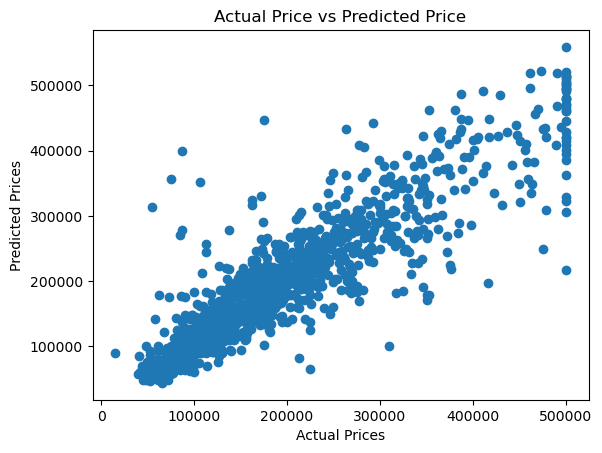

In [176]:
plt.scatter(y_val,xgb.predict(X_val))
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price")
plt.show()

**Hyperparameter Tuning**

In [62]:
from sklearn.model_selection import GridSearchCV


Random Forest

In [63]:
param_grid = {
    'n_estimators' :[100,200,250],
    'max_depth':[None,10,20],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

grid_search = GridSearchCV(RandomForestRegressor(),param_grid=param_grid,cv=5)
grid_search.fit(X_train,y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)


KeyboardInterrupt: 

Gradient Boosting

XGBRegressor

In [ ]:
param_grid = {
    'n_estimors': [10,100,200],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth': [3,5,7],
    'subsample': [0.8,1.0]
}

grid_search = GridSearchCV(GradientBoostingRegressor(),
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_root_mean_squared_error',
                           n_jobs=-1)
grid_search.fit(X_train,y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

In [5]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)
kf

KFold(n_splits=5, random_state=None, shuffle=False)

In [6]:
for train_i,test_i in kf.split([1,2,3,4,5,6,7,8,9]):
    print(train_i,test_i)

[2 3 4 5 6 7 8] [0 1]
[0 1 4 5 6 7 8] [2 3]
[0 1 2 3 6 7 8] [4 5]
[0 1 2 3 4 5 8] [6 7]
[0 1 2 3 4 5 6 7] [8]
